In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(f"C:/Users/Iryna/Downloads/ab_test_data.csv")
df

,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0
...,...,...,...,...
19993,6763ae9a-515c-473e-af00-0d9c4f6a5bc7,2023-07-06 03:27:37.041104,b,0
19994,ac5600f2-4d16-4503-b115-f1a96728b6d1,2023-07-03 04:20:48.572143,a,0
19995,5a8b2630-209b-4d83-b47f-0f3d9dd568a8,2023-07-23 16:23:49.211910,b,1
19996,b572d68b-26ac-432b-9f88-83e0fdee4ca1,2023-07-03 18:26:20.880675,b,0


In [12]:
df.isna().sum()

user_id       0
timestamp     0
test_group    0
conversion    0
dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     19998 non-null  object
 1   timestamp   19998 non-null  object
 2   test_group  19998 non-null  object
 3   conversion  19998 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 625.1+ KB


In [27]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [34]:
df.dtypes

user_id               object
timestamp     datetime64[ns]
test_group            object
conversion             int64
dtype: object

In [33]:
df.isna().sum()

user_id       0
timestamp     0
test_group    0
conversion    0
dtype: int64

In [37]:
df['timestamp'].min(), df['timestamp'].max() #- ПОЧАТОК ТА КІНЕЦЬ ТЕСТУ

(Timestamp('2023-07-03 01:42:34.033708'),
 Timestamp('2023-07-25 01:41:19.152664'))

In [38]:
 df['timestamp'].max() - df['timestamp'].min() # ТРИВАЛІСТЬ ТЕСТУ

Timedelta('21 days 23:58:45.118956')

In [40]:
df.groupby('test_group')['user_id'].nunique().reset_index() # КІЛЬКІСТЬ КОРИСТУВАЧІВ В ОБОХ ГРУПАХ

,test_group,user_id
0,a,10013
1,b,9985


In [45]:
df.groupby('test_group')['conversion'].sum().reset_index(name='conversion_qnty') # КІЛЬКІСТЬ КОНВЕРСІЙ

,test_group,conversion_qnty
0,a,611
1,b,889


In [44]:
df.groupby('test_group')['conversion'].mean().reset_index(name='conversion_rate') # РІВЕНЬ КОНВЕРСІЇ, ЗАГАЛЬНИЙ

,test_group,conversion_rate
0,a,0.061021
1,b,0.089034


In [88]:
df.groupby('test_group').describe()

timestamp                                 \
               count                           mean   
test_group                                            
a              10013  2023-07-14 02:34:29.519821312   
b               9985  2023-07-13 21:37:07.888925952   

                                                                       \
                                   min                            25%   
test_group                                                              
a           2023-07-03 01:46:14.688840  2023-07-08 13:48:52.874817024   
b           2023-07-03 01:42:34.033708  2023-07-08 08:08:48.495631104   

                                                                          \
                                      50%                            75%   
test_group                                                                 
a           2023-07-14 03:49:36.002731008  2023-07-19 14:06:28.688054016   
b           2023-07-13 19:14:14.073116928  2023-07-19 09:59:58.771382016   

                                            conversion                      \
                                   max  std      count      mean  min  25%   
test_group                                                                   
a           2023-07-25 01:41:19.152664  NaN    10013.0  0.061021  0.0  0.0   
b           2023-07-25 01:35:59.130658  NaN     9985.0  0.089034  0.0  0.0   

                                     
            50%  75%  max       std  
test_group                           
a           0.0  0.0  1.0  0.239380  
b           0.0  0.0  1.0  0.284806

In [47]:
from scipy import stats
alpha = 0.05
statistic, pvalue = stats.ttest_ind(df[df['test_group'] == 'b']['conversion'], df[df['test_group'] == 'a']['conversion'], 
alternative = 'two-sided', equal_var = True)

print(f't-statistic: {round(statistic, 2)}, p-value: {round(pvalue, 2)}')

if pvalue < alpha:
    print('Різниця статистично значуща, нульову гіпотезу відхиляємо')
else:
   print('Різниця не значуща, нульову гіпотезу не можна відхилити')


    


t-statistic: 7.53, p-value: 0.0
Різниця статистично значуща, нульову гіпотезу відхиляємо


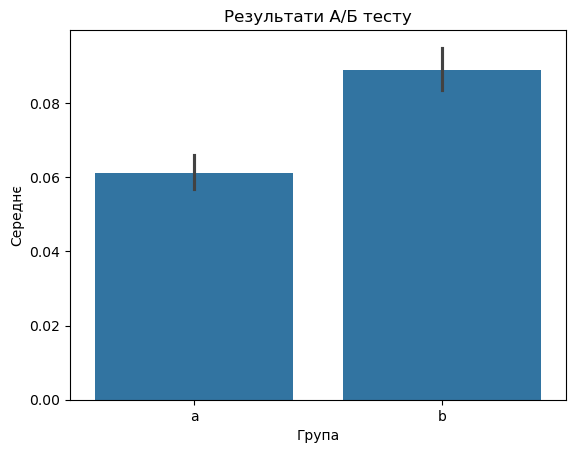

In [48]:
sns.barplot(x=df['test_group'], y=df['conversion'], errorbar=('ci', 95))
plt.title('Результати А/Б тесту')
plt.xlabel('Група')
plt.ylabel('Середнє')
plt.show()

In [50]:
df['date'] = df['timestamp'].dt.date


,user_id,timestamp,test_group,conversion,date
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0,2023-07-04
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0,2023-07-06
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0,2023-07-10
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0,2023-07-20
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0,2023-07-19
...,...,...,...,...,...
19993,6763ae9a-515c-473e-af00-0d9c4f6a5bc7,2023-07-06 03:27:37.041104,b,0,2023-07-06
19994,ac5600f2-4d16-4503-b115-f1a96728b6d1,2023-07-03 04:20:48.572143,a,0,2023-07-03
19995,5a8b2630-209b-4d83-b47f-0f3d9dd568a8,2023-07-23 16:23:49.211910,b,1,2023-07-23
19996,b572d68b-26ac-432b-9f88-83e0fdee4ca1,2023-07-03 18:26:20.880675,b,0,2023-07-03


In [90]:
a_b_daily_conv = df.groupby(['date', 'test_group'])['conversion'].agg(['count', 'sum']).reset_index()
a_b_daily_conv['conversion_rate'] = a_b_daily_conv['sum']/a_b_daily_conv['count']
a_b_daily_conv['conversion_rate_smooth'] = (a_b_daily_conv.groupby('test_group')['conversion_rate'].transform(lambda x: x.rolling(7, min_periods=1).mean()))
a_b_daily_conv = a_b_daily_conv.sort_values(['test_group', 'date'])
a_b_daily_conv


,date,test_group,count,sum,conversion_rate,conversion_rate_smooth
0,2023-07-03,a,412,21,0.050971,0.050971
2,2023-07-04,a,446,29,0.065022,0.057997
4,2023-07-05,a,436,28,0.064220,0.060071
6,2023-07-06,a,457,25,0.054705,0.058730
8,2023-07-07,a,477,36,0.075472,0.062078
10,2023-07-08,a,468,21,0.044872,0.059210
12,2023-07-09,a,453,19,0.041943,0.056743
14,2023-07-10,a,449,28,0.062361,0.058371
16,2023-07-11,a,457,33,0.072210,0.059397
18,2023-07-12,a,428,28,0.065421,0.059569


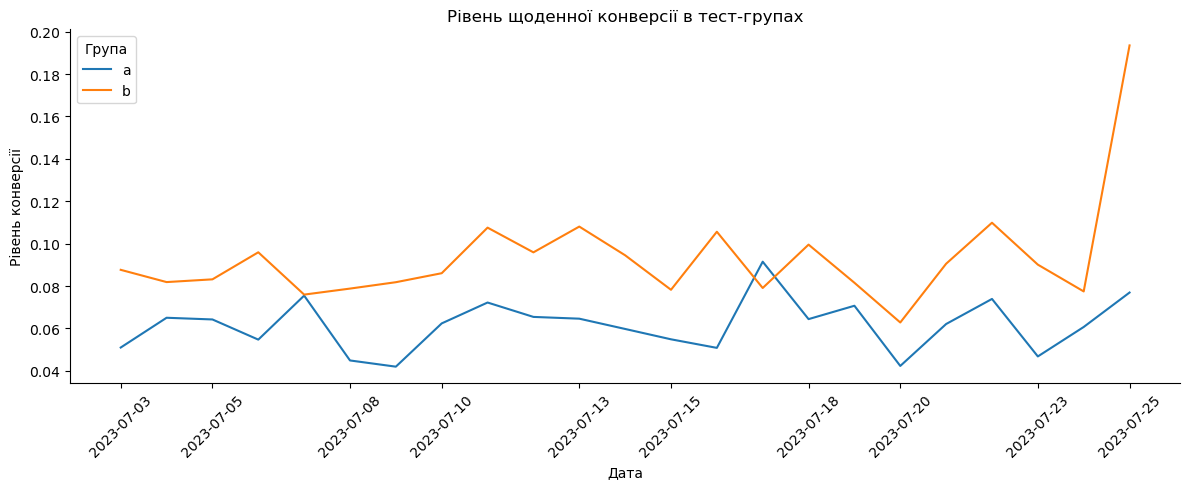

In [93]:
plt.figure(figsize=(12,5))
sns.lineplot(data=a_b_daily_conv, x='date', y='conversion_rate', hue='test_group')
plt.title('Рівень щоденної конверсії в тест-групах')
plt.xlabel('Дата')
plt.ylabel('Рівень конверсії')
plt.xticks(a_b_daily_conv['date'][::5], rotation=45)
plt.legend(title='Група')
sns.despine()
plt.tight_layout()
plt.show()